This  section is about  the visualization of thee diamond lattice with the Nitrogen Vacancy.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from itertools import combinations

In [2]:
def d_l_points(lattice_size):
    lattice_size=lattice_size
    l=range(lattice_size+1)
    points=[]
    for i in l:
        for j in l:
            for k in l:
                new_point=[i,j,k]
                points.append([i+1/2,j+1/2,k])
                points.append([i+1/2,j,k+1/2])
                points.append([i,j+1/2,k+1/2])
                points.append(new_point)
    uni_latt=np.unique(np.array(points),axis=0)
    mask=np.all(uni_latt <= lattice_size,axis=1)
    uni_latt=uni_latt[mask]
    return uni_latt

lattice_size=2

fig=go.Figure()

fcc_0=d_l_points(lattice_size=lattice_size)


def sublat_points(points=fcc_0,lattice_size=lattice_size):
    sublat_points=points.copy()+np.ones(shape=points.shape)*1/4
    mask=np.all(sublat_points<=lattice_size,axis=1)
    return sublat_points[mask]

fcc_1=sublat_points()

allLatPoints=np.concat((fcc_1,fcc_0),axis=0)



def findingNeighbours(allLatPoints):
    tol=1e-4
    neighbours = []
    totalPoints=allLatPoints.shape[0]
    totalPoints=range(totalPoints)
    for i, j in list(combinations(totalPoints,2)):
        sep=allLatPoints[i]-allLatPoints[j]
        sep=np.linalg.norm(sep)
        if ((abs(sep)-(np.sqrt(3)/4))<=tol):
            neighbours.append([i,j])
    return neighbours



def connectingPairs(fig=fig,neighbours=findingNeighbours(allLatPoints),allLatPoints=allLatPoints):
    for aPair in neighbours:
        r1=allLatPoints[aPair[0]]
        r2=allLatPoints[aPair[1]]
        bond=np.vstack((r1,r2))
        fig.add_trace(go.Scatter3d(x=bond[:,0],y=bond[:,1],z=bond[:,2],mode="lines",showlegend=False,line=dict(width=5)))
    return 0


fig.update_layout(dict(title=dict(text="<b>Diamond Lattice</b>",x=0.5),template='plotly_white'))
fig.add_trace(go.Scatter3d(x=fcc_0[:,0],y=fcc_0[:,1],z=fcc_0[:,2],mode="markers",marker=dict(size=6),name="Basis Atoms"))
fig.add_trace(go.Scatter3d(x=fcc_1[:,0],y=fcc_1[:,1],z=fcc_1[:,2],mode="markers",marker=dict(size=6),name="Sublattice Atoms"))
connectingPairs()


fig.show()

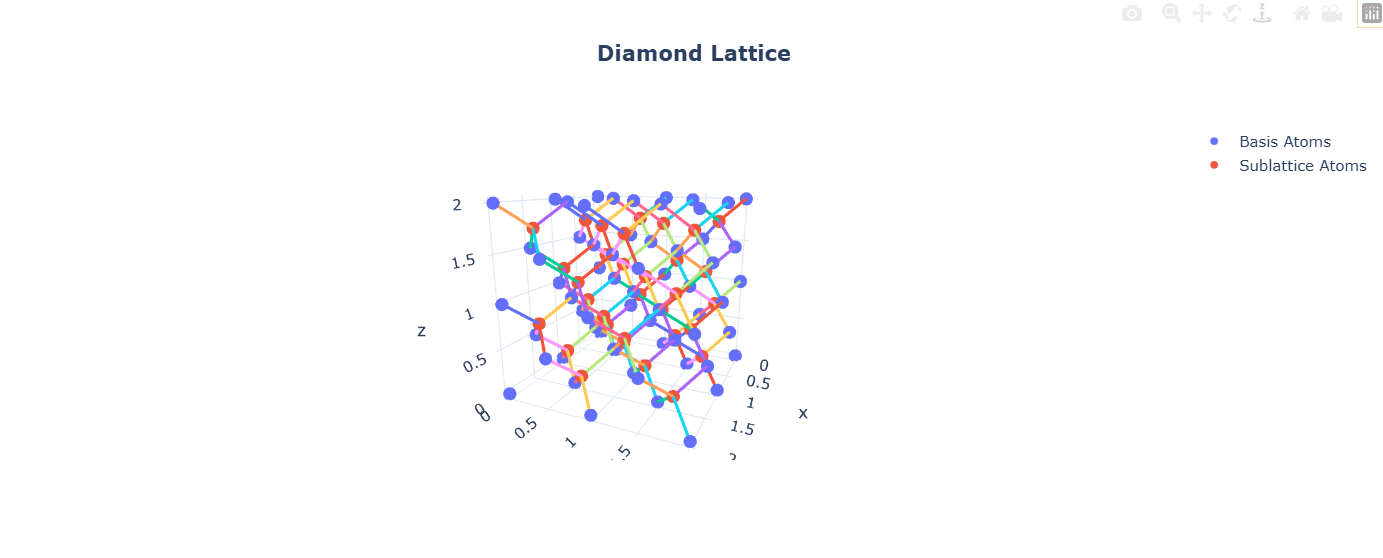